# Retrieval Diversity and Redundancy in RAG
A clean end-to-end notebook for studying relevance, redundancy, and coverage in retrieval for RAG.

This version rewrites the full workflow from scratch, starting with:
1. downloading the 2019 and 2020 TREC Deep Learning query sets from MS MARCO,
2. inspecting what a query and graded relevance judgments look like,
3. building a frozen evaluation set,
4. constructing a judged-document candidate pool,
5. building dense and sparse retrieval representations,
6. implementing baseline and diversity-aware retrieval methods,
7. evaluating both ranking quality and coverage efficiency.

The notebook is organized so that another researcher can read it top to bottom and understand both the experimental setup and the code.

## 0. Research framing

**Goal.** Retrieve a set of documents that covers the meaning of a query while minimizing redundancy.

**Main question.** Can diversity-aware retrieval methods select a smaller, less redundant set of documents than standard retrieval baselines without losing too much useful information?

**Methods implemented in this notebook**
- Dense retrieval
- Sparse retrieval using standard BM25
- Dense-sparse score fusion
- Hybrid pricing
- Hybrid MMR
- Dual residual tracking

**Important design decision for dual residual in this rewrite**
- The sparse side stays close to standard sparse retrieval.
- We do **not** replace sparse retrieval with raw token-overlap coverage scoring.
- Instead, dual residual uses a **weighted BM25-style query**, where query term weights decay over time as their lexical demand is covered.
- Stopping is based on a **combined dense + sparse residual exhaustion signal**, not only a sparse threshold.

## 1. Optional installs

Uncomment and run if the environment does not already have the required libraries.

In [1]:
# %pip install -q ir_datasets sentence-transformers rank_bm25 scikit-learn pandas matplotlib tqdm

## 2. Imports

In [2]:
import json
import math
import os
import pickle
import random
import re
from collections import Counter, defaultdict
from dataclasses import dataclass
from itertools import product
from typing import Dict, List, Tuple, Iterable, Optional

import ir_datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

/users/jacobr1/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Configuration

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATASETS = [
    "msmarco-passage/trec-dl-2019",
    "msmarco-passage/trec-dl-2020",
]

CACHE_DIR = "rag_diversity_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
TOP_K = 10

# Retrieval defaults
DEFAULT_ALPHA = 0.75
DEFAULT_LAMBDA = 0.30
DEFAULT_ETA = 0.35

# Dual residual defaults
DEFAULT_BETA_STOP = 0.50
DEFAULT_MIN_COMBINED_RESIDUAL_FRAC = 0.10
DEFAULT_MIN_COMBINED_SCORE = 0.10

# Coverage thresholds for efficiency metrics
SEMANTIC_THRESHOLDS = [0.80, 0.90, 0.95]
SPARSE_THRESHOLDS = [0.80, 0.90, 0.95]

# Candidate pool controls
MAX_CANDIDATE_DOCS = None   # set to an integer if you want to subsample for faster experiments

# Export controls
RESULTS_CSV = os.path.join(CACHE_DIR, "method_results.csv")
SWEEP_CSV = os.path.join(CACHE_DIR, "dual_residual_sweep.csv")

print("Cache directory:", CACHE_DIR)

Cache directory: rag_diversity_cache


## 4. Load the 2019 and 2020 TREC-DL datasets

These datasets give:
- queries
- qrels with graded relevance labels
- access to the MS MARCO passage store through `docs_store()`

In [4]:
datasets = [ir_datasets.load(name) for name in DATASETS]
datasets

[Dataset(id='msmarco-passage/trec-dl-2019', provides=['docs', 'queries', 'qrels', 'scoreddocs']),
 Dataset(id='msmarco-passage/trec-dl-2020', provides=['docs', 'queries', 'qrels', 'scoreddocs'])]

## 5. Inspect what a query and graded judgments look like

This is the first sanity check in the notebook.

In [5]:
def load_queries_and_qrels(dataset):
    queries = {q.query_id: q.text for q in dataset.queries_iter()}
    qrels = defaultdict(dict)
    for qr in dataset.qrels_iter():
        qrels[qr.query_id][qr.doc_id] = qr.relevance
    return queries, dict(qrels)

all_queries = {}
all_qrels = {}
for ds in datasets:
    q, r = load_queries_and_qrels(ds)
    all_queries.update(q)
    all_qrels.update(r)

sample_qid = sorted(all_qrels.keys())[0]
print("Sample query id:", sample_qid)
print("Sample query text:", all_queries[sample_qid])
print("\nSample qrels for this query:")
print(all_qrels[sample_qid])

Sample query id: 1030303
Sample query text: who is aziz hashim

Sample qrels for this query:
{'1038342': 0, '1042969': 0, '1044043': 0, '1056584': 0, '1070133': 0, '1070134': 0, '1086238': 0, '1104408': 0, '1161432': 0, '1161439': 0, '1166176': 0, '1172906': 0, '1207443': 0, '1227100': 0, '1269099': 0, '1292821': 0, '1292822': 0, '1305520': 0, '1305521': 0, '1305528': 0, '1358683': 0, '1369019': 0, '1376556': 0, '1376558': 0, '1397758': 0, '1402779': 0, '1451846': 0, '1451848': 0, '1451850': 0, '1451851': 0, '1462522': 0, '1492373': 0, '1538148': 0, '1538153': 0, '163871': 0, '1666520': 0, '1777312': 0, '1784767': 0, '1811800': 0, '1813557': 0, '1813561': 0, '1905988': 0, '196026': 0, '2001450': 0, '2057929': 0, '2146415': 0, '2194939': 0, '2205078': 0, '2217415': 0, '2217635': 0, '22484': 0, '226464': 0, '2484376': 0, '2488127': 0, '2563261': 0, '2597066': 0, '2620119': 0, '2628843': 0, '2628844': 0, '2712400': 0, '2740876': 0, '2782702': 0, '288491': 0, '292060': 0, '309441': 0, '310

If you want to inspect a random query with graded labels, run the next cell a few times.

In [6]:
import random

random_qid = random.choice(list(all_qrels.keys()))
print("Random query id:", random_qid)
print("Query:", all_queries[random_qid])
print("Number of judged docs:", len(all_qrels[random_qid]))
print("Top judged docs by grade:")
for doc_id, rel in sorted(all_qrels[random_qid].items(), key=lambda x: (-x[1], x[0]))[:10]:
    print(doc_id, "->", rel)

Random query id: 1106979
Query: define pareto chart in statistics
Number of judged docs: 157
Top judged docs by grade:
3290649 -> 3
8190140 -> 3
1039252 -> 2
2306620 -> 2
2375312 -> 2
2884219 -> 2
3290646 -> 2
3290651 -> 2
348054 -> 2
348057 -> 2


## 6. Build the frozen evaluation set

We keep only queries with at least one relevant document.
That gives a stable query set for consistent benchmarking.

In [7]:
def build_frozen_query_set(queries: Dict[str, str], qrels: Dict[str, Dict[str, int]]):
    queries_frozen = {}
    qrels_frozen = {}
    for qid, text in queries.items():
        judged = qrels.get(qid, {})
        if any(rel > 0 for rel in judged.values()):
            queries_frozen[qid] = text
            qrels_frozen[qid] = judged
    return queries_frozen, qrels_frozen

queries_frozen, qrels_frozen = build_frozen_query_set(all_queries, all_qrels)
print("Frozen query count:", len(queries_frozen))
print("Example query id:", next(iter(queries_frozen)))

Frozen query count: 97
Example query id: 156493


## 7. Build the judged-document candidate pool

To keep experiments controlled and reproducible, we take the union of all judged documents
appearing in the frozen qrels, then fetch the passage text for those docs.

In [8]:
docs_store = datasets[0].docs_store()

candidate_doc_ids = sorted({doc_id for qid in qrels_frozen for doc_id in qrels_frozen[qid]})
if MAX_CANDIDATE_DOCS is not None:
    candidate_doc_ids = candidate_doc_ids[:MAX_CANDIDATE_DOCS]

doc_text = {}
missing_doc_ids = []

for doc_id in tqdm(candidate_doc_ids, desc="Fetching judged passages"):
    doc = docs_store.get(doc_id)
    if doc is None:
        missing_doc_ids.append(doc_id)
        continue
    text = getattr(doc, "text", None)
    if text is None:
        text = str(doc)
    doc_text[doc_id] = text

candidate_doc_ids = [d for d in candidate_doc_ids if d in doc_text]
doc_index = {doc_id: i for i, doc_id in enumerate(candidate_doc_ids)}

print("Candidate docs loaded:", len(candidate_doc_ids))
print("Missing docs:", len(missing_doc_ids))

Fetching judged passages: 100%|████████| 20349/20349 [00:00<00:00, 40076.07it/s]

Candidate docs loaded: 20349
Missing docs: 0


## 8. Inspect a judged document example

In [9]:
sample_doc_id = next(iter(doc_text))
print("Sample doc id:", sample_doc_id)
print(doc_text[sample_doc_id][:1000])

Sample doc id: 1000485
Pseudobulbar palsy is characterized by the inability to control facial muscles, including the tongue. This may manifest as: 1  dysarthria (slowed or slurred speech). 2  dysphagia (difficulty swallowing).seudobulbar palsy is characterized by the inability to control facial muscles, including the tongue. This may manifest as: 1  dysarthria (slowed or slurred speech). 2  dysphagia (difficulty swallowing).


## 9. Tokenization helpers

In [10]:
TOKEN_PATTERN = re.compile(r"[a-z0-9]+")

def simple_tokenize(text: str) -> List[str]:
    return TOKEN_PATTERN.findall(text.lower())

tokenized_docs = [simple_tokenize(doc_text[doc_id]) for doc_id in candidate_doc_ids]
doc_term_freqs = [Counter(tokens) for tokens in tokenized_docs]
doc_lengths = np.array([len(tokens) for tokens in tokenized_docs], dtype=float)
avg_doc_len = float(doc_lengths.mean()) if len(doc_lengths) else 0.0

print("Average tokenized document length:", round(avg_doc_len, 2))

Average tokenized document length: 56.9


## 10. Standard sparse retrieval: BM25

This is the normal sparse baseline.

We will also reuse BM25 components inside dual residual, but with **residual query weights**.
The document side remains standard BM25-style term-frequency scoring.

In [11]:
bm25 = BM25Okapi(tokenized_docs)
print("BM25 index built over", len(tokenized_docs), "documents")

BM25 index built over 20349 documents


## 11. Dense representation

We encode all candidate documents once, normalize them, and keep them in memory.

In [12]:
embed_model = SentenceTransformer(EMBED_MODEL_NAME)

doc_embedding_cache = os.path.join(CACHE_DIR, "doc_embeddings.npy")
if os.path.exists(doc_embedding_cache):
    doc_embeddings = np.load(doc_embedding_cache)
else:
    texts = [doc_text[doc_id] for doc_id in candidate_doc_ids]
    doc_embeddings = embed_model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    np.save(doc_embedding_cache, doc_embeddings)

print("Doc embeddings shape:", doc_embeddings.shape)

Loading weights: 100%|█| 103/103 [00:00<00:00, 988.91it/s, Materializing param=p
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Doc embeddings shape: (20349, 384)


## 12. Query embedding helper

In [13]:
def embed_query(query_text: str) -> np.ndarray:
    return embed_model.encode(
        [query_text],
        convert_to_numpy=True,
        normalize_embeddings=True,
    )[0]

## 13. Core scoring helpers

In [14]:
def normalize_scores(scores: np.ndarray) -> np.ndarray:
    scores = np.asarray(scores, dtype=float)
    if len(scores) == 0:
        return scores
    lo = np.min(scores)
    hi = np.max(scores)
    if hi - lo < 1e-12:
        return np.zeros_like(scores)
    return (scores - lo) / (hi - lo)

def dense_scores_for_query(query_text: str) -> np.ndarray:
    q_emb = embed_query(query_text)
    return np.asarray(doc_embeddings @ q_emb, dtype=float)

def sparse_scores_for_query(query_text: str) -> np.ndarray:
    q_tokens = simple_tokenize(query_text)
    return np.array(bm25.get_scores(q_tokens), dtype=float)

def get_relevance_grade(qid: str, doc_id: str) -> int:
    return int(qrels_frozen.get(qid, {}).get(doc_id, 0))

def upper_triangle_mean(sim_matrix: np.ndarray) -> float:
    n = sim_matrix.shape[0]
    if n < 2:
        return 0.0
    iu = np.triu_indices(n, k=1)
    return float(sim_matrix[iu].mean())

## 14. Weighted BM25 for dual residual

This is the key change.

Instead of replacing sparse retrieval with simple token overlap, we keep the sparse side close to normal BM25.
The difference is that the query now has **residual token weights**.

For a weighted query:
- each query token contributes according to its remaining residual weight
- document scoring still uses BM25-style tf, idf, and document-length normalization

In [15]:
# Extract BM25 internals
BM25_K1 = bm25.k1
BM25_B = bm25.b
BM25_IDF = bm25.idf

def weighted_bm25_scores_from_residual(sparse_residual: Counter) -> np.ndarray:
    scores = np.zeros(len(candidate_doc_ids), dtype=float)
    if not sparse_residual:
        return scores

    for tok, q_weight in sparse_residual.items():
        idf = BM25_IDF.get(tok, 0.0)
        if abs(idf) < 1e-12:
            continue

        for i, tf_counter in enumerate(doc_term_freqs):
            tf = tf_counter.get(tok, 0)
            if tf == 0:
                continue
            denom = tf + BM25_K1 * (1.0 - BM25_B + BM25_B * (doc_lengths[i] / avg_doc_len))
            scores[i] += q_weight * idf * (tf * (BM25_K1 + 1.0) / denom)

    return scores

def build_sparse_query_weights(query_text: str) -> Counter:
    return Counter(simple_tokenize(query_text))

def update_sparse_residual(doc_text_value: str, sparse_residual: Counter, decay: float = 1.0) -> Counter:
    doc_tokens = set(simple_tokenize(doc_text_value))
    new_residual = Counter(sparse_residual)
    for tok in list(new_residual.keys()):
        if tok in doc_tokens:
            new_residual[tok] = max(0.0, new_residual[tok] - decay)
            if new_residual[tok] <= 0:
                del new_residual[tok]
    return new_residual

## 15. Retrieval methods

In [16]:
def retrieve_dense(query_text: str, k: int = TOP_K) -> List[str]:
    scores = dense_scores_for_query(query_text)
    top_idx = np.argsort(-scores)[:k]
    return [candidate_doc_ids[i] for i in top_idx]

def retrieve_sparse(query_text: str, k: int = TOP_K) -> List[str]:
    scores = sparse_scores_for_query(query_text)
    top_idx = np.argsort(-scores)[:k]
    return [candidate_doc_ids[i] for i in top_idx]

def retrieve_fusion(query_text: str, alpha: float = DEFAULT_ALPHA, k: int = TOP_K) -> List[str]:
    dense_scores = normalize_scores(dense_scores_for_query(query_text))
    sparse_scores = normalize_scores(sparse_scores_for_query(query_text))
    fused = alpha * dense_scores + (1.0 - alpha) * sparse_scores
    top_idx = np.argsort(-fused)[:k]
    return [candidate_doc_ids[i] for i in top_idx]

def retrieve_hybrid_mmr(
    query_text: str,
    alpha: float = DEFAULT_ALPHA,
    lambda_div: float = DEFAULT_LAMBDA,
    k: int = TOP_K,
) -> List[str]:
    dense_scores = normalize_scores(dense_scores_for_query(query_text))
    sparse_scores = normalize_scores(sparse_scores_for_query(query_text))
    relevance = alpha * dense_scores + (1.0 - alpha) * sparse_scores

    selected = []
    remaining = set(range(len(candidate_doc_ids)))

    while remaining and len(selected) < k:
        best_i = None
        best_score = -1e18
        for i in remaining:
            if not selected:
                score = relevance[i]
            else:
                sim_to_selected = np.max(doc_embeddings[selected] @ doc_embeddings[i])
                score = relevance[i] - lambda_div * float(sim_to_selected)
            if score > best_score:
                best_score = score
                best_i = i
        selected.append(best_i)
        remaining.remove(best_i)

    return [candidate_doc_ids[i] for i in selected]

def retrieve_hybrid_pricing(
    query_text: str,
    alpha: float = DEFAULT_ALPHA,
    lambda_div: float = DEFAULT_LAMBDA,
    k: int = TOP_K,
) -> List[str]:
    dense_scores = normalize_scores(dense_scores_for_query(query_text))
    sparse_scores = normalize_scores(sparse_scores_for_query(query_text))
    relevance = alpha * dense_scores + (1.0 - alpha) * sparse_scores

    selected = []
    remaining = set(range(len(candidate_doc_ids)))

    while remaining and len(selected) < k:
        best_i = None
        best_score = -1e18
        for i in remaining:
            redundancy = 0.0
            if selected:
                redundancy = float(np.mean(doc_embeddings[selected] @ doc_embeddings[i]))
            score = relevance[i] - lambda_div * redundancy
            if score > best_score:
                best_score = score
                best_i = i
        selected.append(best_i)
        remaining.remove(best_i)

    return [candidate_doc_ids[i] for i in selected]

## 16. Dual residual tracking

This is the main method rewrite.

### Dense side
We maintain:
- a dense residual direction `q_dense_dir`
- a scalar `dense_mass_remaining`

After selecting a document with embedding `d`, we:
1. measure how much of the current semantic direction it covers,
2. subtract that covered direction,
3. renormalize the direction,
4. separately decay the scalar semantic mass so we still have an interpretable stopping signal.

### Sparse side
We maintain residual token weights over the query.
The sparse score is a **weighted BM25 score**, not a raw token-overlap count.

### Stopping
We compute:
- `dense_residual_frac`
- `sparse_residual_frac`

Then combine them:

`combined_residual_frac = beta_stop * dense_residual_frac + (1 - beta_stop) * sparse_residual_frac`

We stop when:
- combined residual demand is small enough, or
- the best remaining document under the residual objective is too weak, or
- we reach `k`

In [17]:
def retrieve_dual_residual(
    query_text: str,
    alpha: float = DEFAULT_ALPHA,
    eta: float = DEFAULT_ETA,
    sparse_decay: float = 1.0,
    beta_stop: float = DEFAULT_BETA_STOP,
    min_combined_residual_frac: float = DEFAULT_MIN_COMBINED_RESIDUAL_FRAC,
    min_combined_score: Optional[float] = DEFAULT_MIN_COMBINED_SCORE,
    k: int = TOP_K,
    return_debug: bool = False,
):
    q_dense_dir = embed_query(query_text).copy()
    dense_mass_remaining = 1.0

    sparse_residual = build_sparse_query_weights(query_text)
    initial_sparse_mass = float(sum(sparse_residual.values())) if sparse_residual else 1.0

    selected = []
    remaining = set(range(len(candidate_doc_ids)))
    history = []

    while remaining and len(selected) < k:
        dense_scores = doc_embeddings @ q_dense_dir
        dense_scores = normalize_scores(dense_scores)

        sparse_scores = weighted_bm25_scores_from_residual(sparse_residual)
        sparse_scores = normalize_scores(sparse_scores)

        combined = alpha * dense_scores + (1.0 - alpha) * sparse_scores

        remaining_list = list(remaining)
        best_i = remaining_list[int(np.argmax(combined[remaining_list]))]
        best_score = float(combined[best_i])

        sparse_mass_remaining = float(sum(sparse_residual.values()))
        sparse_residual_frac = sparse_mass_remaining / initial_sparse_mass if initial_sparse_mass > 0 else 0.0
        dense_residual_frac = dense_mass_remaining
        combined_residual_frac = beta_stop * dense_residual_frac + (1.0 - beta_stop) * sparse_residual_frac

        if len(selected) > 0:
            if combined_residual_frac < min_combined_residual_frac:
                break
            if min_combined_score is not None and best_score < min_combined_score:
                break

        selected.append(best_i)
        remaining.remove(best_i)

        # Dense residual update
        d = doc_embeddings[best_i]
        coverage = max(0.0, float(q_dense_dir @ d))

        q_dense_dir = q_dense_dir - eta * coverage * d
        norm = np.linalg.norm(q_dense_dir)
        if norm > 1e-12:
            q_dense_dir = q_dense_dir / norm

        dense_mass_remaining = max(0.0, dense_mass_remaining * (1.0 - eta * coverage))

        # Sparse residual update
        sparse_residual = update_sparse_residual(
            doc_text[candidate_doc_ids[best_i]],
            sparse_residual,
            decay=sparse_decay,
        )

        history.append({
            "step": len(selected),
            "doc_id": candidate_doc_ids[best_i],
            "best_score": best_score,
            "dense_residual_frac": dense_mass_remaining,
            "sparse_residual_frac": float(sum(sparse_residual.values())) / initial_sparse_mass if initial_sparse_mass > 0 else 0.0,
        })

    selected_doc_ids = [candidate_doc_ids[i] for i in selected]

    if return_debug:
        return selected_doc_ids, history
    return selected_doc_ids

## 17. Evaluation metrics

We evaluate both ranking-style and coverage-style metrics.

In [18]:
def dcg_at_k(retrieved_doc_ids: List[str], qid: str, k: int = TOP_K) -> float:
    score = 0.0
    for rank, doc_id in enumerate(retrieved_doc_ids[:k], start=1):
        rel = get_relevance_grade(qid, doc_id)
        gain = (2 ** rel) - 1
        discount = 1.0 / math.log2(rank + 1)
        score += gain * discount
    return score

def idcg_at_k(qid: str, k: int = TOP_K) -> float:
    rels = sorted(qrels_frozen[qid].values(), reverse=True)[:k]
    score = 0.0
    for rank, rel in enumerate(rels, start=1):
        gain = (2 ** rel) - 1
        discount = 1.0 / math.log2(rank + 1)
        score += gain * discount
    return score

def ndcg_at_k(retrieved_doc_ids: List[str], qid: str, k: int = TOP_K) -> float:
    denom = idcg_at_k(qid, k)
    if denom == 0:
        return 0.0
    return dcg_at_k(retrieved_doc_ids, qid, k) / denom

def irrelevant_at_k(retrieved_doc_ids: List[str], qid: str, k: int = TOP_K) -> int:
    return sum(1 for doc_id in retrieved_doc_ids[:k] if get_relevance_grade(qid, doc_id) <= 0)

def hit_grade3(retrieved_doc_ids: List[str], qid: str, k: int = TOP_K) -> int:
    return int(any(get_relevance_grade(qid, doc_id) == 3 for doc_id in retrieved_doc_ids[:k]))

def redundancy_at_k(retrieved_doc_ids: List[str], k: int = TOP_K) -> float:
    ids = retrieved_doc_ids[:k]
    if len(ids) < 2:
        return 0.0
    emb = np.vstack([doc_embeddings[doc_index[d]] for d in ids])
    sim = emb @ emb.T
    return upper_triangle_mean(sim)

## 18. Coverage metrics

The current judged candidate pool makes pure coverage difficult to define perfectly, but we can still build useful proxies.

### Semantic coverage
For each relevant judged document for a query, compute its maximum cosine similarity to the selected set.
Then average those maxima, weighting by relevance grade.

This measures how well the selected set semantically covers the judged relevant set.

### Sparse coverage
Take the original query token multiset.
Measure the fraction of query token mass that appears in at least one selected document, counting repeated tokens using the original query counts.

### Efficiency
How many retrieved documents are needed to exceed given semantic or sparse coverage thresholds?

In [19]:
def relevant_doc_ids_for_query(qid: str) -> List[str]:
    return [doc_id for doc_id, rel in qrels_frozen[qid].items() if rel > 0 and doc_id in doc_index]

def semantic_coverage(retrieved_doc_ids: List[str], qid: str, k: int = TOP_K) -> float:
    selected = [doc_id for doc_id in retrieved_doc_ids[:k] if doc_id in doc_index]
    relevant = relevant_doc_ids_for_query(qid)

    if not selected or not relevant:
        return 0.0

    selected_emb = np.vstack([doc_embeddings[doc_index[d]] for d in selected])
    relevant_emb = np.vstack([doc_embeddings[doc_index[d]] for d in relevant])

    sim = relevant_emb @ selected_emb.T
    max_sim = sim.max(axis=1)

    weights = np.array([qrels_frozen[qid][d] for d in relevant], dtype=float)
    if weights.sum() <= 0:
        return float(max_sim.mean())
    return float(np.average(max_sim, weights=weights))

def sparse_query_coverage(retrieved_doc_ids: List[str], query_text: str, k: int = TOP_K) -> float:
    query_weights = build_sparse_query_weights(query_text)
    if not query_weights:
        return 0.0

    covered = Counter()
    for doc_id in retrieved_doc_ids[:k]:
        doc_tokens = set(simple_tokenize(doc_text[doc_id]))
        for tok in query_weights:
            if tok in doc_tokens:
                covered[tok] = query_weights[tok]

    covered_mass = float(sum(covered.values()))
    total_mass = float(sum(query_weights.values()))
    return covered_mass / total_mass if total_mass > 0 else 0.0

def docs_needed_for_semantic_coverage(retrieved_doc_ids: List[str], qid: str, threshold: float) -> Optional[int]:
    for j in range(1, len(retrieved_doc_ids) + 1):
        if semantic_coverage(retrieved_doc_ids[:j], qid, k=j) >= threshold:
            return j
    return None

def docs_needed_for_sparse_coverage(retrieved_doc_ids: List[str], query_text: str, threshold: float) -> Optional[int]:
    for j in range(1, len(retrieved_doc_ids) + 1):
        if sparse_query_coverage(retrieved_doc_ids[:j], query_text, k=j) >= threshold:
            return j
    return None

## 19. Unified evaluation wrapper

In [20]:
def evaluate_single_query(qid: str, method_name: str, retrieved_doc_ids: List[str], query_text: str, k: int = TOP_K) -> Dict:
    row = {
        "qid": qid,
        "method": method_name,
        "k": k,
        "nDCG@k": ndcg_at_k(retrieved_doc_ids, qid, k),
        "irrelevant@k": irrelevant_at_k(retrieved_doc_ids, qid, k),
        "redundancy@k": redundancy_at_k(retrieved_doc_ids, k),
        "hit_grade3@k": hit_grade3(retrieved_doc_ids, qid, k),
        "semantic_coverage@k": semantic_coverage(retrieved_doc_ids, qid, k),
        "sparse_coverage@k": sparse_query_coverage(retrieved_doc_ids, query_text, k),
        "docs_retrieved": len(retrieved_doc_ids[:k]),
    }
    for thr in SEMANTIC_THRESHOLDS:
        row[f"docs_to_semantic_{thr:.2f}"] = docs_needed_for_semantic_coverage(retrieved_doc_ids[:k], qid, thr)
    for thr in SPARSE_THRESHOLDS:
        row[f"docs_to_sparse_{thr:.2f}"] = docs_needed_for_sparse_coverage(retrieved_doc_ids[:k], query_text, thr)
    return row

def evaluate_method_over_queries(method_name: str, retrieve_fn, qids: Optional[List[str]] = None, k: int = TOP_K, verbose: bool = True) -> pd.DataFrame:
    if qids is None:
        qids = list(queries_frozen.keys())

    rows = []
    iterator = tqdm(qids, desc=f"Evaluating {method_name}") if verbose else qids
    for qid in iterator:
        query_text = queries_frozen[qid]
        retrieved_doc_ids = retrieve_fn(query_text, k=k)
        rows.append(evaluate_single_query(qid, method_name, retrieved_doc_ids, query_text, k=k))
    return pd.DataFrame(rows)

## 20. Quick spot-check on one query

In [21]:
test_qid = random.choice(list(queries_frozen.keys()))
test_query = queries_frozen[test_qid]
print("Test qid:", test_qid)
print("Query:", test_query)

for name, fn in [
    ("dense", retrieve_dense),
    ("sparse_bm25", retrieve_sparse),
    ("fusion", lambda q, k=TOP_K: retrieve_fusion(q, alpha=0.75, k=k)),
    ("dual_residual", lambda q, k=TOP_K: retrieve_dual_residual(q, alpha=0.75, eta=0.35, sparse_decay=1.0, beta_stop=0.5, min_combined_residual_frac=0.10, min_combined_score=0.10, k=k)),
]:
    docs = fn(test_query, k=TOP_K)
    print("\nMethod:", name)
    print("Top docs:", docs[:5])
    print("nDCG@10:", round(ndcg_at_k(docs, test_qid, 10), 4))
    print("hit_grade3@10:", hit_grade3(docs, test_qid, 10))
    print("semantic_coverage@10:", round(semantic_coverage(docs, test_qid, 10), 4))
    print("sparse_coverage@10:", round(sparse_query_coverage(docs, test_query, 10), 4))

Test qid: 1117099
Query: what is a active margin

Method: dense
Top docs: ['6122722', '8093934', '1445087', '3349612', '3543106']
nDCG@10: 0.8803
hit_grade3@10: 1
semantic_coverage@10: 0.7344
sparse_coverage@10: 0.8

Method: sparse_bm25
Top docs: ['1445087', '7610604', '8446502', '6177939', '8093934']
nDCG@10: 0.7354
hit_grade3@10: 1
semantic_coverage@10: 0.7261
sparse_coverage@10: 1.0

Method: fusion
Top docs: ['6122722', '8093934', '1445087', '3349612', '8446505']
nDCG@10: 0.7322
hit_grade3@10: 1
semantic_coverage@10: 0.7125
sparse_coverage@10: 1.0

Method: dual_residual
Top docs: ['6122722', '7610604', '8093934', '3349612', '5752877']
nDCG@10: 0.4249
hit_grade3@10: 1
semantic_coverage@10: 0.6206
sparse_coverage@10: 1.0


## 21. Define experiment methods

You can edit these settings before running the full benchmark.

In [22]:
METHODS = {
    "dense": lambda q, k=TOP_K: retrieve_dense(q, k=k),
    "sparse_bm25": lambda q, k=TOP_K: retrieve_sparse(q, k=k),
    "fusion_a075": lambda q, k=TOP_K: retrieve_fusion(q, alpha=0.75, k=k),
    "pricing_a075_l030": lambda q, k=TOP_K: retrieve_hybrid_pricing(q, alpha=0.75, lambda_div=0.30, k=k),
    "mmr_a075_l030": lambda q, k=TOP_K: retrieve_hybrid_mmr(q, alpha=0.75, lambda_div=0.30, k=k),
    "dualres_a075_eta035_sd1_b050_r010_s010": (
        lambda q, k=TOP_K: retrieve_dual_residual(
            q,
            alpha=0.75,
            eta=0.35,
            sparse_decay=1.0,
            beta_stop=0.50,
            min_combined_residual_frac=0.10,
            min_combined_score=0.10,
            k=k,
        )
    ),
}
list(METHODS.keys())

['dense',
 'sparse_bm25',
 'fusion_a075',
 'pricing_a075_l030',
 'mmr_a075_l030',
 'dualres_a075_eta035_sd1_b050_r010_s010']

## 22. Run the main benchmark

This may take a while depending on the number of queries and candidate documents.

In [23]:
all_results = []
for method_name, method_fn in METHODS.items():
    df = evaluate_method_over_queries(method_name, method_fn, k=TOP_K, verbose=True)
    all_results.append(df)

results_df = pd.concat(all_results, ignore_index=True)
results_df.to_csv(RESULTS_CSV, index=False)
print("Saved results to:", RESULTS_CSV)
results_df.head()

Evaluating mmr_a075_l030: 100%|█████████████████| 97/97 [01:24<00:00,  1.15it/s]
Evaluating dualres_a075_eta035_sd1_b050_r010_s010: 100%|█| 97/97 [00:05<00:00, 1

Saved results to: rag_diversity_cache/method_results.csv



/tmp/ipykernel_3681565/3654136559.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat(all_results, ignore_index=True)


,qid,method,k,nDCG@k,irrelevant@k,redundancy@k,hit_grade3@k,semantic_coverage@k,sparse_coverage@k,docs_retrieved,docs_to_semantic_0.80,docs_to_semantic_0.90,docs_to_semantic_0.95,docs_to_sparse_0.80,docs_to_sparse_0.90,docs_to_sparse_0.95
0,156493,dense,10,0.773123,0,0.787190,0,0.771769,1.000000,10,NaN,NaN,NaN,3.0,3.0,3.0
1,1110199,dense,10,0.741698,0,0.725232,1,0.791434,0.800000,10,NaN,NaN,NaN,2.0,NaN,NaN
2,1063750,dense,10,0.615258,0,0.795632,0,0.680914,0.571429,10,NaN,NaN,NaN,NaN,NaN,NaN
3,130510,dense,10,0.909317,0,0.794624,1,0.832168,1.000000,10,7.0,NaN,NaN,1.0,1.0,1.0
4,489204,dense,10,0.187202,3,0.812548,0,0.600929,1.000000,10,NaN,NaN,NaN,4.0,4.0,4.0


## 23. Aggregate method-level results

In [24]:
def mean_ignore_none(series: pd.Series) -> float:
    vals = pd.to_numeric(series, errors="coerce")
    return float(vals.dropna().mean()) if vals.dropna().shape[0] else np.nan

agg = results_df.groupby("method").agg({
    "nDCG@k": "mean",
    "irrelevant@k": "mean",
    "redundancy@k": "mean",
    "hit_grade3@k": "mean",
    "semantic_coverage@k": "mean",
    "sparse_coverage@k": "mean",
    "docs_retrieved": "mean",
}).sort_values("nDCG@k", ascending=False)

for thr in SEMANTIC_THRESHOLDS:
    agg[f"docs_to_semantic_{thr:.2f}"] = results_df.groupby("method")[f"docs_to_semantic_{thr:.2f}"].apply(mean_ignore_none)
for thr in SPARSE_THRESHOLDS:
    agg[f"docs_to_sparse_{thr:.2f}"] = results_df.groupby("method")[f"docs_to_sparse_{thr:.2f}"].apply(mean_ignore_none)

agg.round(4)

,nDCG@k,irrelevant@k,redundancy@k,hit_grade3@k,semantic_coverage@k,sparse_coverage@k,docs_retrieved,docs_to_semantic_0.80,docs_to_semantic_0.90,docs_to_semantic_0.95,docs_to_sparse_0.80,docs_to_sparse_0.90,docs_to_sparse_0.95
method,,,,,,,,,,,,,
dense,0.6115,2.2268,0.7359,0.7216,0.7367,0.8708,10.0000,5.6000,5.00,6.7500,3.2603,4.1000,3.9375
fusion_a075,0.5954,2.6082,0.7105,0.7526,0.7353,0.9223,10.0000,5.8438,4.00,4.3333,2.8046,3.5469,3.4194
pricing_a075_l030,0.5601,2.9072,0.6581,0.7423,0.7402,0.9309,10.0000,5.7812,6.00,6.0000,2.1364,2.7910,2.8000
mmr_a075_l030,0.5453,2.9794,0.6402,0.7423,0.7435,0.9456,10.0000,5.6452,6.25,7.0000,2.2747,3.0685,3.1127
dualres_a075_eta035_sd1_b050_r010_s010,0.3872,4.1031,0.4603,0.6701,0.7062,0.9944,8.4021,3.6250,3.50,3.0000,1.8542,2.5895,2.5319
sparse_bm25,0.3864,4.7113,0.5230,0.6495,0.6921,0.9727,10.0000,5.8571,NaN,NaN,2.1474,3.3614,3.3902


## 24. Visualizations

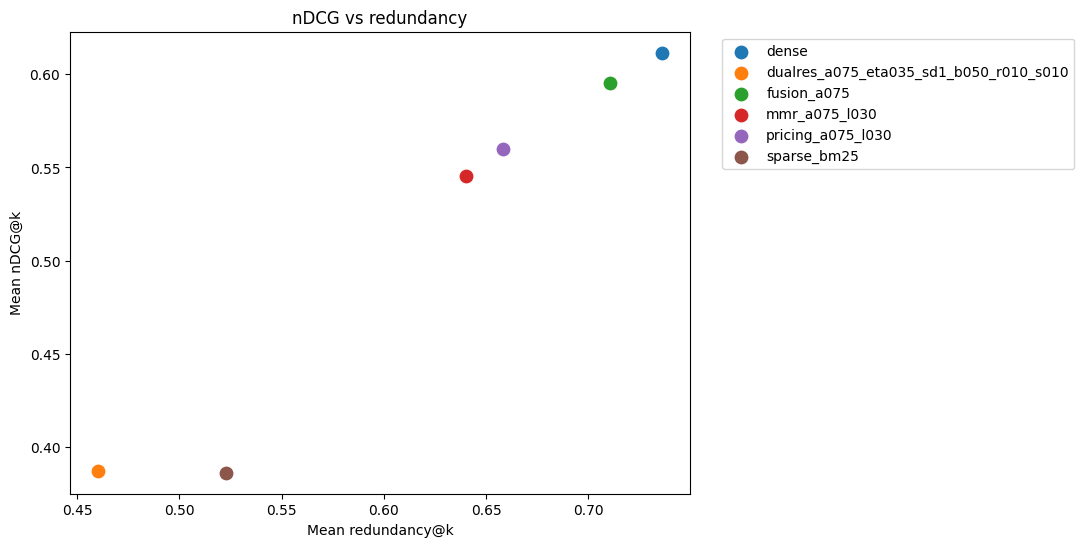

In [25]:
plt.figure(figsize=(8, 6))
for method_name, g in results_df.groupby("method"):
    plt.scatter(g["redundancy@k"].mean(), g["nDCG@k"].mean(), label=method_name, s=80)
plt.xlabel("Mean redundancy@k")
plt.ylabel("Mean nDCG@k")
plt.title("nDCG vs redundancy")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

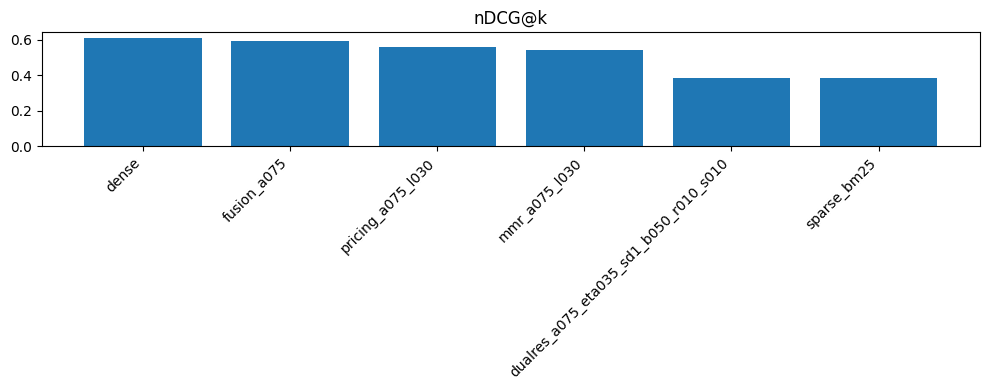

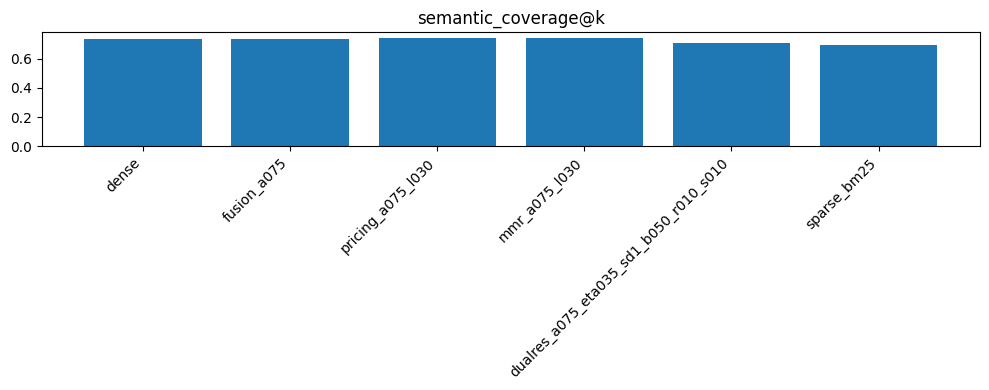

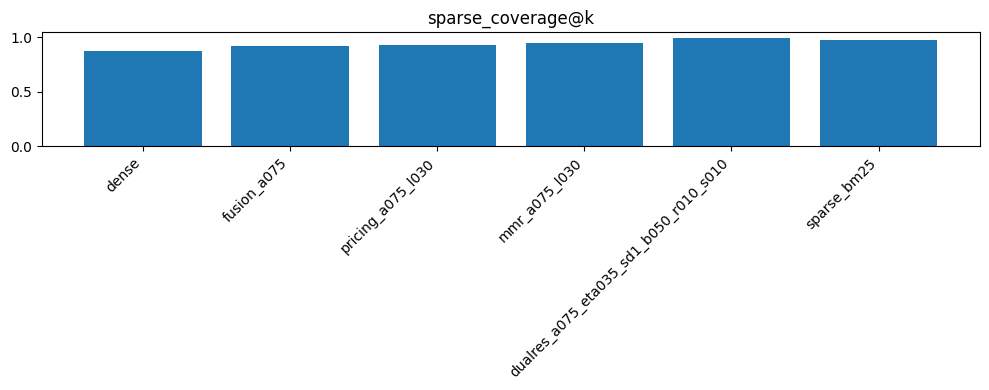

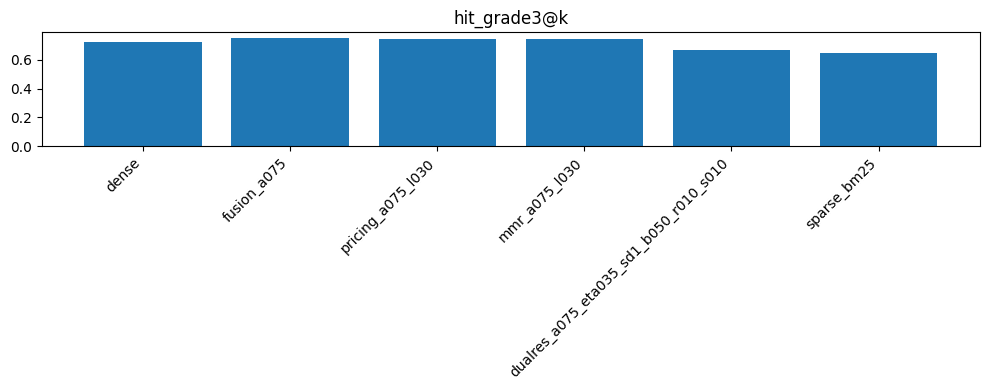

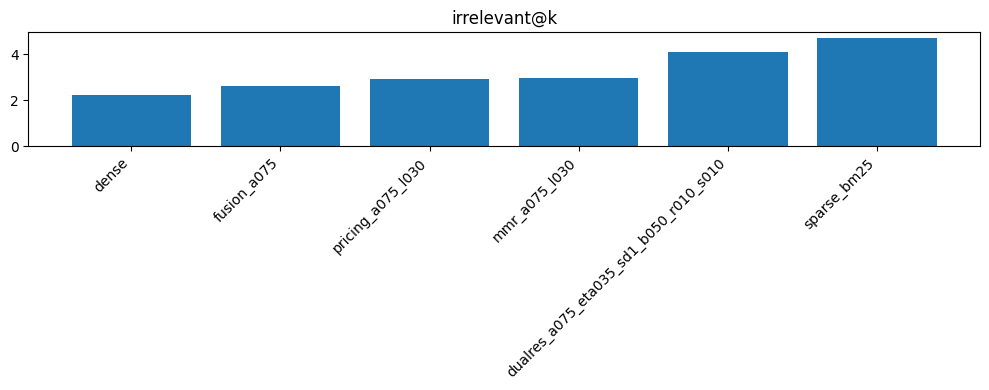

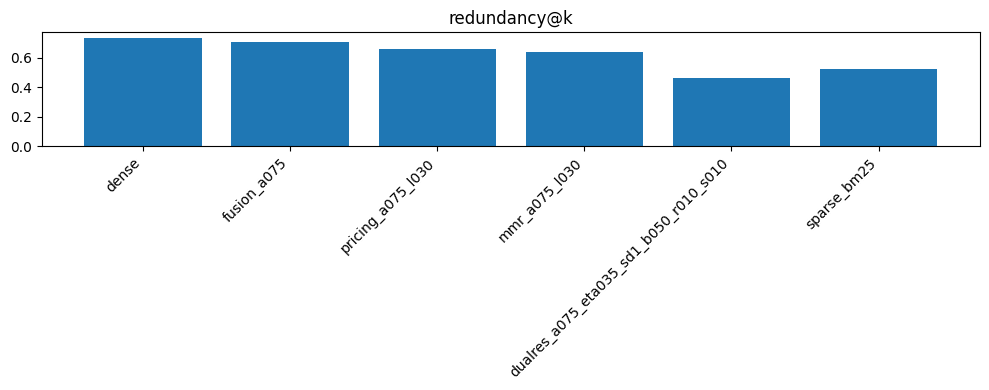

In [26]:
metrics_to_plot = ["nDCG@k", "semantic_coverage@k", "sparse_coverage@k", "hit_grade3@k", "irrelevant@k", "redundancy@k"]
for metric in metrics_to_plot:
    plt.figure(figsize=(10, 4))
    order = agg.index.tolist()
    vals = [agg.loc[m, metric] for m in order]
    plt.bar(order, vals)
    plt.xticks(rotation=45, ha="right")
    plt.title(metric)
    plt.tight_layout()
    plt.show()

## 25. Dual residual parameter sweep

This is the main sweep for the rewritten dual residual method.

Parameters:
- `alpha`: dense versus sparse score weighting
- `eta`: strength of semantic residual subtraction
- `sparse_decay`: strength of lexical residual decay
- `beta_stop`: dense versus sparse weighting in the stopping criterion
- `min_combined_residual_frac`: threshold for residual exhaustion
- `min_combined_score`: threshold for best remaining candidate score

In [27]:
alpha_grid = [0.50, 0.75, 0.90]
eta_grid = [0.10, 0.25, 0.35, 0.50]
sparse_decay_grid = [0.50, 1.00, 2.00]
beta_stop_grid = [0.25, 0.50, 0.75]
min_combined_residual_frac_grid = [0.00, 0.05, 0.10, 0.20]
min_combined_score_grid = [None, 0.05, 0.10, 0.15]

dual_param_grid = list(product(
    alpha_grid,
    eta_grid,
    sparse_decay_grid,
    beta_stop_grid,
    min_combined_residual_frac_grid,
    min_combined_score_grid,
))

len(dual_param_grid)

1728

Running the full sweep can be expensive. You may want to start on a subset of queries first.

In [28]:
def run_dual_residual_sweep(
    qids: Optional[List[str]] = None,
    k: int = TOP_K,
    verbose: bool = True,
) -> pd.DataFrame:
    if qids is None:
        qids = list(queries_frozen.keys())

    rows = []
    iterator = tqdm(dual_param_grid, desc="Dual residual sweep") if verbose else dual_param_grid

    for alpha, eta, sparse_decay, beta_stop, min_resid, min_score in iterator:
        method_name = (
            f"dualres_a{alpha:.2f}_eta{eta:.2f}_sd{sparse_decay:.2f}_"
            f"b{beta_stop:.2f}_r{min_resid:.2f}_s{min_score if min_score is not None else 'None'}"
        )

        df = evaluate_method_over_queries(
            method_name,
            lambda q, k=k, alpha=alpha, eta=eta, sparse_decay=sparse_decay, beta_stop=beta_stop, min_resid=min_resid, min_score=min_score: retrieve_dual_residual(
                q,
                alpha=alpha,
                eta=eta,
                sparse_decay=sparse_decay,
                beta_stop=beta_stop,
                min_combined_residual_frac=min_resid,
                min_combined_score=min_score,
                k=k,
            ),
            qids=qids,
            k=k,
            verbose=False,
        )

        summary = {
            "method": method_name,
            "alpha": alpha,
            "eta": eta,
            "sparse_decay": sparse_decay,
            "beta_stop": beta_stop,
            "min_combined_residual_frac": min_resid,
            "min_combined_score": min_score,
            "nDCG@k": df["nDCG@k"].mean(),
            "irrelevant@k": df["irrelevant@k"].mean(),
            "redundancy@k": df["redundancy@k"].mean(),
            "hit_grade3@k": df["hit_grade3@k"].mean(),
            "semantic_coverage@k": df["semantic_coverage@k"].mean(),
            "sparse_coverage@k": df["sparse_coverage@k"].mean(),
            "docs_retrieved": df["docs_retrieved"].mean(),
        }
        rows.append(summary)

    sweep_df = pd.DataFrame(rows)
    sweep_df.to_csv(SWEEP_CSV, index=False)
    return sweep_df

### Small pilot sweep
Start here before running the full query set.

In [29]:
pilot_qids = list(queries_frozen.keys())[:20]
dual_sweep_pilot_df = run_dual_residual_sweep(qids=pilot_qids, k=TOP_K, verbose=True)
dual_sweep_pilot_df.sort_values(["semantic_coverage@k", "nDCG@k"], ascending=False).head(20)

Dual residual sweep: 100%|██████████████████| 1728/1728 [36:31<00:00,  1.27s/it]


,method,alpha,eta,sparse_decay,beta_stop,min_combined_residual_frac,min_combined_score,nDCG@k,irrelevant@k,redundancy@k,hit_grade3@k,semantic_coverage@k,sparse_coverage@k,docs_retrieved
1152,dualres_a0.90_eta0.10_sd0.50_b0.25_r0.00_sNone,0.9,0.1,0.5,0.25,0.00,NaN,0.561237,2.4,0.678833,0.75,0.738358,0.952718,10.0
1153,dualres_a0.90_eta0.10_sd0.50_b0.25_r0.00_s0.05,0.9,0.1,0.5,0.25,0.00,0.05,0.561237,2.4,0.678833,0.75,0.738358,0.952718,10.0
1154,dualres_a0.90_eta0.10_sd0.50_b0.25_r0.00_s0.1,0.9,0.1,0.5,0.25,0.00,0.10,0.561237,2.4,0.678833,0.75,0.738358,0.952718,10.0
1155,dualres_a0.90_eta0.10_sd0.50_b0.25_r0.00_s0.15,0.9,0.1,0.5,0.25,0.00,0.15,0.561237,2.4,0.678833,0.75,0.738358,0.952718,10.0
1156,dualres_a0.90_eta0.10_sd0.50_b0.25_r0.05_sNone,0.9,0.1,0.5,0.25,0.05,NaN,0.561237,2.4,0.678833,0.75,0.738358,0.952718,10.0
1157,dualres_a0.90_eta0.10_sd0.50_b0.25_r0.05_s0.05,0.9,0.1,0.5,0.25,0.05,0.05,0.561237,2.4,0.678833,0.75,0.738358,0.952718,10.0
1158,dualres_a0.90_eta0.10_sd0.50_b0.25_r0.05_s0.1,0.9,0.1,0.5,0.25,0.05,0.10,0.561237,2.4,0.678833,0.75,0.738358,0.952718,10.0
1159,dualres_a0.90_eta0.10_sd0.50_b0.25_r0.05_s0.15,0.9,0.1,0.5,0.25,0.05,0.15,0.561237,2.4,0.678833,0.75,0.738358,0.952718,10.0
1160,dualres_a0.90_eta0.10_sd0.50_b0.25_r0.10_sNone,0.9,0.1,0.5,0.25,0.10,NaN,0.561237,2.4,0.678833,0.75,0.738358,0.952718,10.0
1161,dualres_a0.90_eta0.10_sd0.50_b0.25_r0.10_s0.05,0.9,0.1,0.5,0.25,0.10,0.05,0.561237,2.4,0.678833,0.75,0.738358,0.952718,10.0


### Full sweep
Uncomment when ready.

In [ ]:
dual_sweep_df = run_dual_residual_sweep(qids=list(queries_frozen.keys()), k=TOP_K, verbose=True)
dual_sweep_df.sort_values(["semantic_coverage@k", "nDCG@k"], ascending=False).head(25)

Dual residual sweep:  67%|█████████▎    | 1155/1728 [1:52:48<1:11:52,  7.53s/it]

## 26. Inspect stopping behavior for one query

In [ ]:
inspect_qid = random.choice(list(queries_frozen.keys()))
inspect_query = queries_frozen[inspect_qid]
selected_docs, history = retrieve_dual_residual(
    inspect_query,
    alpha=0.75,
    eta=0.35,
    sparse_decay=1.0,
    beta_stop=0.50,
    min_combined_residual_frac=0.10,
    min_combined_score=0.10,
    k=TOP_K,
    return_debug=True,
)

print("Inspect qid:", inspect_qid)
print("Query:", inspect_query)
print("Selected docs:", selected_docs)

history_df = pd.DataFrame(history)
history_df

In [ ]:
if len(history_df):
    plt.figure(figsize=(8, 4))
    plt.plot(history_df["step"], history_df["dense_residual_frac"], marker="o", label="dense residual frac")
    plt.plot(history_df["step"], history_df["sparse_residual_frac"], marker="o", label="sparse residual frac")
    plt.xlabel("step")
    plt.ylabel("remaining fraction")
    plt.title("Dual residual exhaustion over retrieval steps")
    plt.legend()
    plt.show()

## 27. Qualitative inspection

This is useful for understanding why a method got a good or bad score.

In [ ]:
def show_retrieval_for_query(qid: str, retrieve_fn, k: int = TOP_K, max_chars: int = 300):
    query_text = queries_frozen[qid]
    docs = retrieve_fn(query_text, k=k)
    print("QID:", qid)
    print("Query:", query_text)
    print("nDCG@k:", round(ndcg_at_k(docs, qid, k), 4))
    print("hit_grade3@k:", hit_grade3(docs, qid, k))
    print("semantic_coverage@k:", round(semantic_coverage(docs, qid, k), 4))
    print("sparse_coverage@k:", round(sparse_query_coverage(docs, query_text, k), 4))
    print()

    for rank, doc_id in enumerate(docs[:k], start=1):
        rel = get_relevance_grade(qid, doc_id)
        snippet = doc_text[doc_id][:max_chars].replace("\n", " ")
        print(f"{rank:>2}. doc_id={doc_id}  rel={rel}")
        print("   ", snippet)
        print()

qual_qid = random.choice(list(queries_frozen.keys()))
show_retrieval_for_query(qual_qid, METHODS["dense"])

## 28. Suggested analysis questions for the writeup

After running the experiments, these are the questions this notebook is designed to answer.

1. Does dense retrieval maximize nDCG at the cost of high redundancy?
2. Does sparse BM25 improve diversity but lower ranking quality?
3. Does score fusion behave more like dense retrieval or does it meaningfully improve coverage?
4. Do pricing and MMR fail because the judged candidate pool contains tight relevance clusters?
5. Does dual residual tracking provide a smoother tradeoff between relevance and redundancy?
6. How often does each method retrieve at least one grade-3 document?
7. Which methods reach high semantic or sparse coverage with fewer documents?
8. How sensitive is dual residual to:
   - semantic update strength (`eta`)
   - lexical decay (`sparse_decay`)
   - stopping thresholds
9. Is combined residual stopping better than forcing every method to always retrieve exactly `k` documents?

## 29. Export tables for the paper

In [ ]:
agg_round = agg.reset_index().round(4)
paper_table_path = os.path.join(CACHE_DIR, "paper_table_methods.csv")
agg_round.to_csv(paper_table_path, index=False)
paper_table_path

## 30. Minimal run checklist

If you are reopening this notebook later, here is the shortest path to reproducing the experiments:

1. Run imports and config.
2. Load datasets and inspect queries/qrels.
3. Build the frozen query set.
4. Build the judged-document candidate pool.
5. Build BM25 and dense embeddings.
6. Run the benchmark methods in Section 22.
7. Aggregate and visualize in Sections 23 and 24.
8. Run the dual residual sweep in Section 25.
9. Inspect stopping behavior and qualitative examples.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1) CONFIG
# =========================================================
TOP_DUAL = 5   # how many best dual residual configs to compare
TOP_PER_FAMILY = 2  # how many non-dual variants to keep per family in the final display

# Pick the metric used to define "best" dual residual configs
# Change this if you want to prioritize something else
PRIMARY_SORT = None

# =========================================================
# 2) HELPERS
# =========================================================
def detect_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def family_from_method(m):
    m = str(m)
    if m == "dense":
        return "dense"
    if m == "bm25":
        return "bm25"
    if m.startswith("fusion_"):
        return "fusion"
    if m.startswith("dual_residual"):
        return "dual_residual"
    if m.startswith("hybrid_mmr"):
        return "hybrid_mmr"
    if m.startswith("HybridPricing") or m.startswith("hybrid_pricing"):
        return "hybrid_pricing"
    return "other"

def pretty_method_name(m):
    m = str(m)
    if m == "dense":
        return "Dense"
    if m == "bm25":
        return "BM25"
    if m.startswith("fusion_"):
        return m.replace("fusion_minmax_", "Fusion ")
    if m.startswith("dual_residual"):
        return m
    if m.startswith("hybrid_mmr"):
        return m.replace("hybrid_mmr_", "Hybrid-MMR ")
    if m.startswith("HybridPricing") or m.startswith("hybrid_pricing"):
        return m
    return m

def round_existing(df, cols_to_round):
    out = df.copy()
    for c, nd in cols_to_round.items():
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce").round(nd)
    return out

# =========================================================
# 3) FIND IMPORTANT COLUMNS
# =========================================================
# Baseline summary table
base_df = summary_df.copy()

# Dual residual sweep table
dr_df = dual_sweep_df.copy()

ndcg_col = detect_col(dr_df, ["nDCG@k", "mean_ndcg@k", "ndcg@k", "ndcg"])
sem_cov_col = detect_col(dr_df, ["semantic_coverage@k", "semantic_coverage", "sem_coverage@k"])
sparse_cov_col = detect_col(dr_df, ["sparse_coverage@k", "sparse_coverage", "lexical_coverage@k", "lexical_coverage"])
red_col = detect_col(dr_df, ["mean_redundancy@k", "redundancy@k", "redundancy"])
irr_col = detect_col(dr_df, ["mean_irrelevant@k", "irrelevant@k", "irrelevant"])
docs_col = detect_col(dr_df, ["docs_selected", "num_docs_selected", "num_selected", "selected_docs", "docs_used"])
tokens_col = detect_col(dr_df, ["tokens_selected", "num_tokens_selected", "tokens_used", "selected_tokens"])

if PRIMARY_SORT is None:
    if sem_cov_col and ndcg_col:
        sort_cols = [sem_cov_col, ndcg_col]
        sort_ascending = [False, False]
    elif sem_cov_col:
        sort_cols = [sem_cov_col]
        sort_ascending = [False]
    elif ndcg_col:
        sort_cols = [ndcg_col]
        sort_ascending = [False]
    else:
        raise ValueError("Could not find a coverage or nDCG column in dual_sweep_df.")
else:
    sort_cols = [PRIMARY_SORT]
    sort_ascending = [False]

print("Using dual residual sort columns:", sort_cols)

# =========================================================
# 4) TAKE TOP DUAL RESIDUAL CONFIGS
# =========================================================
best_dual = (
    dr_df.sort_values(sort_cols, ascending=sort_ascending)
         .head(TOP_DUAL)
         .copy()
)

# Make sure it has a method column
if "method" not in best_dual.columns:
    best_dual["method"] = [
        f"dual_residual_best_{i}" for i in range(len(best_dual))
    ]

best_dual["family"] = "dual_residual_best"

# =========================================================
# 5) PREP BASELINE TABLE
# =========================================================
base_df = base_df.copy()
if "family" not in base_df.columns:
    base_df["family"] = base_df["method"].apply(family_from_method)

# remove fake dual residuals if present (no penalties)
if "lambda_mmr" in base_df.columns:
    mask_fake_dual = (
        base_df["method"].astype(str).str.startswith("dual_residual")
        & pd.to_numeric(base_df["lambda_mmr"], errors="coerce").fillna(0.0).eq(0.0)
    )
    if "lambda_sparse" in base_df.columns:
        mask_fake_dual &= pd.to_numeric(base_df["lambda_sparse"], errors="coerce").fillna(0.0).eq(0.0)
    base_df = base_df.loc[~mask_fake_dual].copy()

# keep only top few per non-dual family so table/plots aren't huge
base_df_small = (
    base_df.sort_values("mean_ndcg@k", ascending=False)
           .groupby("family", group_keys=False)
           .head(TOP_PER_FAMILY)
           .copy()
)

# =========================================================
# 6) ALIGN COLUMNS BETWEEN BASELINES AND DUAL SWEEP
# =========================================================
# Create baseline-compatible columns in best_dual if needed
if "mean_ndcg@k" not in best_dual.columns and ndcg_col is not None:
    best_dual["mean_ndcg@k"] = best_dual[ndcg_col]

if red_col is not None and "mean_redundancy@k" not in best_dual.columns:
    best_dual["mean_redundancy@k"] = best_dual[red_col]

if irr_col is not None and "mean_irrelevant@k" not in best_dual.columns:
    best_dual["mean_irrelevant@k"] = best_dual[irr_col]

# preserve semantic / sparse coverage if they exist
if sem_cov_col is not None and sem_cov_col != "semantic_coverage@k":
    best_dual["semantic_coverage@k"] = best_dual[sem_cov_col]
elif sem_cov_col == "semantic_coverage@k":
    pass

if sparse_cov_col is not None and sparse_cov_col != "sparse_coverage@k":
    best_dual["sparse_coverage@k"] = best_dual[sparse_cov_col]
elif sparse_cov_col == "sparse_coverage@k":
    pass

# If baselines do not have coverage columns, create NaNs so concat works
for c in ["semantic_coverage@k", "sparse_coverage@k", "docs_selected", "tokens_selected"]:
    if c not in base_df_small.columns:
        base_df_small[c] = np.nan

if docs_col is not None and "docs_selected" not in best_dual.columns:
    best_dual["docs_selected"] = best_dual[docs_col]
if tokens_col is not None and "tokens_selected" not in best_dual.columns:
    best_dual["tokens_selected"] = best_dual[tokens_col]

# Ensure key cols exist in best_dual too
for c in ["mean_ndcg@k", "mean_irrelevant@k", "mean_redundancy@k", "semantic_coverage@k", "sparse_coverage@k", "docs_selected", "tokens_selected"]:
    if c not in best_dual.columns:
        best_dual[c] = np.nan

# Add num_queries if missing
if "num_queries" not in best_dual.columns:
    if "num_queries" in base_df_small.columns:
        best_dual["num_queries"] = base_df_small["num_queries"].iloc[0]
    else:
        best_dual["num_queries"] = np.nan

# =========================================================
# 7) BUILD FINAL COMPARISON TABLE
# =========================================================
compare_cols = [
    "family", "method", "num_queries",
    "mean_ndcg@k", "mean_irrelevant@k", "mean_redundancy@k",
    "semantic_coverage@k", "sparse_coverage@k",
    "docs_selected", "tokens_selected",
    "alpha", "lambda_mmr", "lambda_sparse", "M", "beta_stop", "sem_gain_threshold"
]
compare_cols = [c for c in compare_cols if c in base_df_small.columns or c in best_dual.columns]

comparison_df = pd.concat(
    [
        base_df_small[[c for c in compare_cols if c in base_df_small.columns]],
        best_dual[[c for c in compare_cols if c in best_dual.columns]],
    ],
    ignore_index=True,
    sort=False,
)

# Drop duplicate method names if any
comparison_df = comparison_df.drop_duplicates(subset=["method"]).copy()

# Add prettier labels for plotting
comparison_df["plot_name"] = comparison_df["method"].apply(pretty_method_name)

# Round for readability
comparison_df = round_existing(
    comparison_df,
    {
        "num_queries": 0,
        "mean_ndcg@k": 4,
        "mean_irrelevant@k": 2,
        "mean_redundancy@k": 3,
        "semantic_coverage@k": 3,
        "sparse_coverage@k": 3,
        "docs_selected": 2,
        "tokens_selected": 0,
        "alpha": 2,
        "lambda_mmr": 3,
        "lambda_sparse": 3,
        "M": 0,
        "beta_stop": 2,
        "sem_gain_threshold": 3,
    }
)

comparison_df = comparison_df.sort_values(
    ["mean_ndcg@k", "semantic_coverage@k"] if "semantic_coverage@k" in comparison_df.columns else ["mean_ndcg@k"],
    ascending=False
).reset_index(drop=True)

display(comparison_df)

# =========================================================
# 8) PLOTS
# =========================================================
plot_df = comparison_df.copy()

# 8a) nDCG bar chart
plt.figure(figsize=(10, 5))
plt.bar(plot_df["plot_name"], plot_df["mean_ndcg@k"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Mean nDCG@k")
plt.title("Best Dual Residual Configs vs Other Methods: nDCG")
plt.tight_layout()
plt.show()

# 8b) Irrelevant docs bar chart
if "mean_irrelevant@k" in plot_df.columns:
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["plot_name"], plot_df["mean_irrelevant@k"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Mean Irrelevant@k")
    plt.title("Best Dual Residual Configs vs Other Methods: Irrelevant Docs")
    plt.tight_layout()
    plt.show()

# 8c) Redundancy bar chart
if "mean_redundancy@k" in plot_df.columns:
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["plot_name"], plot_df["mean_redundancy@k"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Mean Redundancy@k")
    plt.title("Best Dual Residual Configs vs Other Methods: Redundancy")
    plt.tight_layout()
    plt.show()

# 8d) Coverage bar chart(s)
if "semantic_coverage@k" in plot_df.columns and plot_df["semantic_coverage@k"].notna().any():
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["plot_name"], plot_df["semantic_coverage@k"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Semantic Coverage@k")
    plt.title("Best Dual Residual Configs vs Other Methods: Semantic Coverage")
    plt.tight_layout()
    plt.show()

if "sparse_coverage@k" in plot_df.columns and plot_df["sparse_coverage@k"].notna().any():
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["plot_name"], plot_df["sparse_coverage@k"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Sparse Coverage@k")
    plt.title("Best Dual Residual Configs vs Other Methods: Sparse Coverage")
    plt.tight_layout()
    plt.show()

# 8e) Efficiency plots if available
if "docs_selected" in plot_df.columns and plot_df["docs_selected"].notna().any():
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["plot_name"], plot_df["docs_selected"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Docs Selected")
    plt.title("Best Dual Residual Configs vs Other Methods: Documents Used")
    plt.tight_layout()
    plt.show()

if "tokens_selected" in plot_df.columns and plot_df["tokens_selected"].notna().any():
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["plot_name"], plot_df["tokens_selected"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Tokens Selected")
    plt.title("Best Dual Residual Configs vs Other Methods: Token Budget")
    plt.tight_layout()
    plt.show()

# 8f) Scatter: relevance vs non-redundancy
if "mean_redundancy@k" in plot_df.columns:
    scatter_df = plot_df.copy()
    scatter_df["non_redundancy@k"] = 1.0 - pd.to_numeric(scatter_df["mean_redundancy@k"], errors="coerce")

    plt.figure(figsize=(8, 6))
    plt.scatter(scatter_df["non_redundancy@k"], scatter_df["mean_ndcg@k"])

    for _, r in scatter_df.iterrows():
        plt.annotate(r["plot_name"], (r["non_redundancy@k"], r["mean_ndcg@k"]), textcoords="offset points", xytext=(4,4), fontsize=8)

    plt.xlabel("1 - Redundancy@k (higher = better)")
    plt.ylabel("Mean nDCG@k")
    plt.title("Relevance vs Non-Redundancy")
    plt.tight_layout()
    plt.show()

# 8g) Scatter: semantic coverage vs irrelevance
if (
    "semantic_coverage@k" in plot_df.columns
    and plot_df["semantic_coverage@k"].notna().any()
    and "mean_irrelevant@k" in plot_df.columns
):
    plt.figure(figsize=(8, 6))
    plt.scatter(plot_df["semantic_coverage@k"], plot_df["mean_irrelevant@k"])

    for _, r in plot_df.iterrows():
        if pd.notna(r["semantic_coverage@k"]) and pd.notna(r["mean_irrelevant@k"]):
            plt.annotate(r["plot_name"], (r["semantic_coverage@k"], r["mean_irrelevant@k"]), textcoords="offset points", xytext=(4,4), fontsize=8)

    plt.xlabel("Semantic Coverage@k")
    plt.ylabel("Mean Irrelevant@k (lower = better)")
    plt.title("Coverage vs Irrelevance")
    plt.tight_layout()
    plt.show()